# Tutorial — DRVI with DDP: why `find_unused_parameters` matters

Trains the same DRVI fit as [the PBMC tutorial](pbmc.ipynb) under multi-GPU DDP and
benchmarks it against a single-GPU baseline — wall-clock time, peak GPU memory, and fit
quality. See [Getting Started](../getting-started.md) for the plain single-GPU call
this extends; this notebook is worth reading once you're training on peaks × cells
matrices large enough that a single GPU's epoch time is the bottleneck.

`DRVI.train` (really `UnsupervisedTrainingMixin.train`) has no dedicated `strategy=`
parameter — a Lightning strategy flows through its `**trainer_kwargs` straight into
`scvi.train.Trainer`. Inside a single Jupyter kernel process, DDP needs Lightning's
notebook-safe strategy aliases (they fork worker processes themselves) rather than
plain `"ddp"`, which expects an external multi-process launcher like `srun`/`torchrun`:
`strategy="ddp_notebook_find_unused_parameters_true"` and
`strategy="ddp_notebook_find_unused_parameters_false"`.

**`find_unused_parameters=False` actually fails for DRVI, trained the ordinary way —
and it's worth knowing exactly why, not just that it does.** `DRVIModule`
(`scvi.external.drvi._module`) subclasses `scvi.module.VAE`, which *unconditionally*
constructs `self.l_encoder` — an `Encoder` for the library-size latent variable — in
`__init__` (`scvi/module/_vae.py`), regardless of settings. But it only actually
*calls* `l_encoder` in the forward pass when `use_observed_lib_size=False`; when
`use_observed_lib_size=True` (the default `VAE.__init__` ships, which DRVI inherits and
`DRVI(atac, n_latent=32)` never overrides), the library size is read directly from
observed counts instead, and `l_encoder`'s parameters never receive a gradient. That's
a genuine, structural unused submodule under DRVI's normal default — not a per-batch
fluke `find_unused_parameters=False`'s "walk the graph after every backward pass" logic
could ever paper over — so DDP catches it immediately with a clear, actionable error
(reproduced below) rather than silently hanging or corrupting gradients.

The lesson generalizes: "this branch is picked by static config, not per-batch data" is
*not* the same question `find_unused_parameters` is asking. It asks "does every
parameter that exists get used in *this* forward pass" — and a whole submodule can be
unconditionally constructed yet unconditionally unused. Below: the failure, reproduced
on purpose, followed by the working config and the actual benchmark.

:::{note}
Every DDP rank reaches the code after `model.train(...)` returns, but
`BaseModelClass.save()` has no rank guard of its own — without one, every rank would
race to `os.makedirs`/`torch.save` the same path. `model.trainer` is set as a real
attribute the moment `.train()` returns (scvi-tools' own post-training internals use
exactly this pattern), so everything after training — saving, reading
`model.history`, building `embed` — must be guarded by
`if model.trainer.is_global_zero:`.
:::


## 0. Data — same PBMC multiome sample as the main tutorial

Same 10x PBMC multiome sample, same peak-filtering/QC as [the main
tutorial](pbmc.ipynb)'s Section 1. This benchmark only needs the peaks × cells matrix
DRVI itself trains on (`DRVI.setup_anndata(atac, batch_key=None)`), not the RNA-based
cell-type calls, so that half of Section 1 (Leiden clustering, marker scoring) is
skipped here — only `rna`'s QC metrics are used, for the same joint QC mask.


In [1]:
import shutil
import urllib.request
from pathlib import Path

DATA = Path("data")
DATA.mkdir(exist_ok=True)
BASE = "https://cf.10xgenomics.com/samples/cell-arc/2.0.0/pbmc_granulocyte_sorted_10k"
matrix_path = DATA / "pbmc_multiome_filtered_feature_bc_matrix.h5"
if not matrix_path.exists():
    # cf.10xgenomics.com's WAF 403s urllib's default User-Agent (curl/browser UAs are
    # fine) -- set one explicitly rather than switching HTTP libraries for one request.
    url = f"{BASE}/pbmc_granulocyte_sorted_10k_filtered_feature_bc_matrix.h5"
    req = urllib.request.Request(url, headers={"User-Agent": "curl/8.0"})
    with urllib.request.urlopen(req) as response, open(matrix_path, "wb") as f:
        shutil.copyfileobj(response, f)
print(matrix_path, matrix_path.stat().st_size / 1e6, "MB")


data/pbmc_multiome_filtered_feature_bc_matrix.h5 192.125528 MB


In [2]:
import re

import scanpy as sc

raw = sc.read_10x_h5(matrix_path, gex_only=False)
raw.var_names_make_unique()

rna = raw[:, raw.var["feature_types"] == "Gene Expression"].copy()
atac = raw[:, raw.var["feature_types"] == "Peaks"].copy()

# canonical chr:start-end peaks on primary chromosomes only
PEAK_RE = re.compile(r"^chr([1-9]|1[0-9]|2[0-2]|X|Y):\d+-\d+$")
atac = atac[:, atac.var_names.str.match(PEAK_RE)].copy()

sc.pp.calculate_qc_metrics(rna, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)
# same joint RNA+ATAC QC mask as the main tutorial's Section 1, so this benchmark
# trains on the same cells -- just without the RNA-derived cell-type calls this
# notebook doesn't need.
keep_cells = (rna.obs["total_counts"] >= 500) & (atac.obs["total_counts"] >= 1000)
atac = atac[keep_cells].copy()

sc.pp.filter_genes(atac, min_cells=10)

# most-accessible peaks only -- keeps a CPU-scale DRVI fit tractable, same as the
# main tutorial
N_PEAKS = 20_000
top_peaks = atac.var["total_counts"].sort_values(ascending=False).index[:N_PEAKS]
atac = atac[:, atac.var_names.isin(top_peaks)].copy()

print(f"atac {atac.shape}")


/allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/ddp-benchmark-tutorial/.venv-drvi/lib/python3.13/site-packages/scanpy/readwrite.py:322: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return AnnData(matrix, obs=obs_dict, var=var_dict)


atac (11566, 20000)


## 1. Three configs, each its own process

`ddp_bench_worker.py` (next to this notebook) trains one config and exits. Each config
below is launched as its own **subprocess**, not a function call in this kernel
process — necessary, not just tidy: CUDA cannot be re-initialized in a process that
forks *after* already touching CUDA, and Lightning's notebook-safe DDP strategies fork
worker processes from whichever process calls `.train()`. Once one config touches CUDA
in this kernel process, every later config's fork would inherit an already-initialized
CUDA context and break — one fresh process per config sidesteps that entirely. `atac`
is written once to a scratch h5ad so every worker trains on the exact same input
without repeating the QC above.

`ddp_find_unused_false` is run **expecting** it to fail (see above) — its subprocess
call is checked for the specific error, not treated as a bug when it's there.


In [3]:
atac.write_h5ad(DATA / "_ddp_bench_atac.h5ad")

CONFIGS = [
    {"name": "single_gpu", "devices": "1", "strategy": None, "expect_failure": False},
    {"name": "ddp_find_unused_false", "devices": "2",
     "strategy": "ddp_notebook_find_unused_parameters_false", "expect_failure": True},
    {"name": "ddp_find_unused_true", "devices": "2",
     "strategy": "ddp_notebook_find_unused_parameters_true", "expect_failure": False},
]


In [4]:
import subprocess
import sys

UNUSED_PARAMS_MSG = "parameters that were not used in producing the loss"

# Inherits this kernel's own cwd (docs/tutorials, same as `DATA` above) -- ddp_bench_worker.py
# lives right next to this notebook.
for cfg in CONFIGS:
    argv = [sys.executable, "ddp_bench_worker.py", cfg["name"], cfg["devices"]]
    if cfg["strategy"]:
        argv.append(cfg["strategy"])
    print("running:", " ".join(argv))
    result = subprocess.run(argv, capture_output=True, text=True)

    if cfg["expect_failure"]:
        if result.returncode == 0:
            raise RuntimeError(
                f"{cfg['name']} was expected to fail (unused parameters) but succeeded -- "
                "the DRVI/scvi-tools version in use may no longer build an always-unused "
                "l_encoder under use_observed_lib_size=True; re-check the claim above."
            )
        if UNUSED_PARAMS_MSG not in result.stderr:
            print(result.stderr[-4000:])
            raise RuntimeError(f"{cfg['name']} failed, but not with the expected error")
        # The one line that actually matters, out of a much longer DDP traceback.
        culprit = next(line for line in result.stderr.splitlines() if UNUSED_PARAMS_MSG in line)
        print(f"failed as expected:\n  {culprit.strip()}")
        continue

    if result.returncode != 0:
        print(result.stdout[-2000:])
        print(result.stderr[-4000:])
        raise RuntimeError(f"{cfg['name']} failed unexpectedly (exit {result.returncode})")
    print(f"succeeded: {cfg['name']}")


running: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/ddp-benchmark-tutorial/.venv-drvi/bin/python ddp_bench_worker.py single_gpu 1


succeeded: single_gpu
running: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/ddp-benchmark-tutorial/.venv-drvi/bin/python ddp_bench_worker.py ddp_find_unused_false 2 ddp_notebook_find_unused_parameters_false


failed as expected:
  torch.multiprocessing.spawn.ProcessRaisedException: It looks like your LightningModule has parameters that were not used in producing the loss returned by training_step. If this is intentional, you must enable the detection of unused parameters in DDP, either by setting the string value `strategy='ddp_find_unused_parameters_true'` or by setting the flag in the strategy with `strategy=DDPStrategy(find_unused_parameters=True)`.
running: /allen/programs/celltypes/workgroups/hct/mike.cuoco/scads_drvi/.claude/worktrees/ddp-benchmark-tutorial/.venv-drvi/bin/python ddp_bench_worker.py ddp_find_unused_true 2 ddp_notebook_find_unused_parameters_true


succeeded: ddp_find_unused_true


## 2. Compare wall-clock time, peak memory, and fit quality

Only `single_gpu` and `ddp_find_unused_true` produced a trained model —
`ddp_find_unused_false` never gets past its first backward pass, so there is nothing to
benchmark for it (that's the point of the previous section, not a gap here).


In [5]:
import json

import pandas as pd

RESULTS = {}
for cfg in CONFIGS:
    if cfg["expect_failure"]:
        continue
    name = cfg["name"]
    metrics = json.loads((DATA / f"ddp_bench_{name}_metrics.json").read_text())
    history = {}
    for p in sorted(DATA.glob(f"ddp_bench_{name}_history_*.csv")):
        split = p.stem.removeprefix(f"ddp_bench_{name}_history_")
        history[split] = pd.read_csv(p, index_col=0)
    RESULTS[name] = {"metrics": metrics, "history": history}

comparison = pd.DataFrame(
    {
        name: {
            "devices": r["metrics"]["devices"],
            "strategy": r["metrics"]["strategy"] or "(none)",
            "wall_clock_s": round(r["metrics"]["elapsed_s"], 1),
            "peak_mem_gb": round(r["metrics"]["peak_mem_gb"], 2),
            "final_train_elbo": round(r["history"]["elbo_train"].iloc[-1, 0], 1)
            if "elbo_train" in r["history"] else float("nan"),
            "final_val_elbo": round(r["history"]["elbo_validation"].iloc[-1, 0], 1)
            if "elbo_validation" in r["history"] else float("nan"),
            "n_vanished": f"{r['metrics']['n_vanished']}/{r['metrics']['n_dims']}",
        }
        for name, r in RESULTS.items()
    }
).T
comparison


,devices,strategy,wall_clock_s,peak_mem_gb,final_train_elbo,final_val_elbo,n_vanished
single_gpu,1,(none),204.2,3.79,20833.2,21007.1,0/32
ddp_find_unused_true,2,ddp_notebook_find_unused_parameters_true,152.9,4.41,20853.1,21008.7,0/32


`max_epochs` is identical across both configs, but `ddp_find_unused_true`
(`devices=2`) sees roughly half as many optimizer steps per epoch as the single-GPU
baseline: each replica processes its own `batch_size=256` per step, so the effective
global batch size doubles. That's an inherent, expected property of data-parallel
scaling — not a bug — and worth keeping in mind when reading `final_train_elbo`/
`final_val_elbo` above as "trained under the same epoch budget," not "took the same
number of gradient steps."


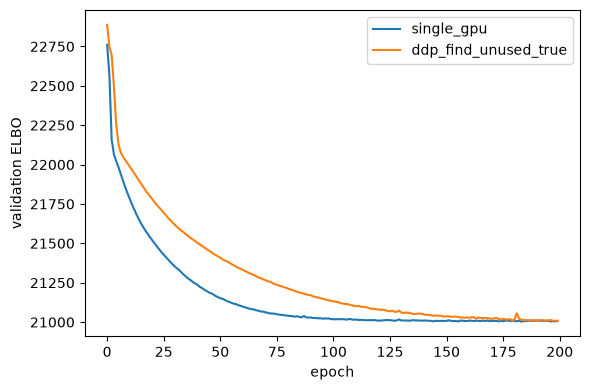

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for name, r in RESULTS.items():
    if "elbo_validation" in r["history"]:
        df = r["history"]["elbo_validation"]
        ax.plot(df.index, df.iloc[:, 0], label=name)
ax.set_xlabel("epoch")
ax.set_ylabel("validation ELBO")
ax.legend()
fig.tight_layout()
fig;


## Results

`ddp_find_unused_false` failed immediately, exactly as predicted from `l_encoder` above
-- confirming that's a real, structural property of DRVI's default configuration, not
a hypothetical. The other two configs, on this ~11.5k-cell x 20k-peak PBMC fit:

- **Wall-clock**: 2-GPU DDP (`ddp_find_unused_true`) finished in ~153s vs. ~204s for
  the single-GPU baseline -- about 25% faster, not the ~2x a naive "twice the GPUs"
  guess would predict. Expected: DDP still does the same 200 epochs' worth of gradient
  *directions*, just split across replicas with half as many steps each, and pays a
  fixed per-step all-reduce cost the single-GPU run never does.
- **Peak memory**: ~4.4 GB/GPU under DDP vs. ~3.8 GB single-GPU -- each DDP replica
  holds the same model, plus NCCL's gradient-bucket buffers, so *per-GPU* memory goes
  up even though the batch each GPU sees is unchanged.
- **Fit quality**: final train/validation ELBO essentially match between the two
  (within ~20 nats on a ~21,000-nat scale), and both leave the same 0/32 dimensions
  vanished -- DDP with the correct `find_unused_parameters` setting reproduces the
  single-GPU fit's quality, it just gets there faster.
